# FPN Backbone Comparison (ResNet34, ResNet50, ResNet101)

## 1. Environment Setup

In [1]:
!pip -q install -U "pillow<12" opencv-python tqdm pandas matplotlib segmentation-models-pytorch timm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 143.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 18.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but

In [2]:
import torch
import cv2
import PIL
import tqdm
import segmentation_models_pytorch as smp

print("✅ torch:", torch.__version__)
print("✅ cv2:", cv2.__version__)
print("✅ PIL:", PIL.__version__)
print("✅ smp:", smp.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


✅ torch: 2.10.0+cu128
✅ cv2: 4.13.0
✅ PIL: 11.3.0
✅ smp: 0.5.0
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


## 2. Imports and Google Drive

In [3]:
import os
import gc
import cv2
import json
import math
import time
import random
import shutil
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from tqdm.auto import tqdm

import segmentation_models_pytorch as smp

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

from google.colab import drive
drive.mount("/content/drive", force_remount=False)


Torch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
Mounted at /content/drive


## 3. Paths

In [4]:
SRC_ROOT = Path("/content/drive/MyDrive/Lab2025/LiuZhentao/Blurred Marking/20260402-new/datasets/Final-Dataset-0414")
DST_ROOT = Path("/content/Final-Dataset")
if DST_ROOT.exists():
    shutil.rmtree(DST_ROOT)
shutil.copytree(SRC_ROOT, DST_ROOT)
print("copied to:", DST_ROOT)


copied to: /content/Final-Dataset


In [5]:
# Path helpers
def resolve_drive_path(path_str: str) -> Path:
    candidates = [
        path_str,
        path_str.replace("/content/drive/My Drive", "/content/drive/MyDrive"),
        path_str.replace("/content/drive/MyDrive", "/content/drive/My Drive"),
    ]
    for c in candidates:
        p = Path(c)
        if p.exists():
            return p
    return Path(candidates[0])


def pick_existing(parent: Path, names: List[str]) -> Optional[Path]:
    for n in names:
        p = parent / n
        if p.exists():
            return p
    return None


# Data paths
DATA_ROOT = Path("/content/Final-Dataset")

OUTPUT_ROOT = resolve_drive_path(
    "/content/drive/MyDrive/Lab2025/LiuZhentao/Blurred Marking/20260402-new/Outputs_A100_fpn_compare-0417"
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print("OUTPUT_ROOT =", OUTPUT_ROOT)

TRAIN_DIR = pick_existing(DATA_ROOT, ["train", "Train"])
VAL_DIR   = pick_existing(DATA_ROOT, ["val", "Val", "valid", "Valid"])
TEST_DIR  = pick_existing(DATA_ROOT, ["test", "Test"])

assert TRAIN_DIR is not None, f"train dir not found under {DATA_ROOT}"
assert VAL_DIR   is not None, f"val dir not found under {DATA_ROOT}"
assert TEST_DIR  is not None, f"test dir not found under {DATA_ROOT}"

IMG_SUBDIR  = "img"
MASK_SUBDIR = "mask"
assert (TRAIN_DIR / IMG_SUBDIR).exists(), f"Missing: {TRAIN_DIR / IMG_SUBDIR}"
assert (TRAIN_DIR / MASK_SUBDIR).exists(), f"Missing: {TRAIN_DIR / MASK_SUBDIR}"
assert (VAL_DIR / IMG_SUBDIR).exists(),   f"Missing: {VAL_DIR / IMG_SUBDIR}"
assert (VAL_DIR / MASK_SUBDIR).exists(),  f"Missing: {VAL_DIR / MASK_SUBDIR}"
assert (TEST_DIR / IMG_SUBDIR).exists(),  f"Missing: {TEST_DIR / IMG_SUBDIR}"
assert (TEST_DIR / MASK_SUBDIR).exists(), f"Missing: {TEST_DIR / MASK_SUBDIR}"

# Global configuration
GLOBAL_SEED = 42
NUM_CLASSES = 2
FG_CLASS_ID = 1

NUM_WORKERS = 0
PIN_MEMORY = True

USE_AMP = True
USE_SIMPLE_AUG = False  # Matches the SegFormer comparison setup: no extra augmentation by default.
USE_CLASS_WEIGHTS = True
CLASS_WEIGHTS = [1.0, 3.0]  # [bg, fg]

CE_WEIGHT = 1.0
DICE_WEIGHT = 1.0
DICE_MODE = "pos_only"
DICE_LOG_MODES = ["pos_only", "all"]

BOUNDARY_TOL = 2
BOUNDARY_KERNEL = 3
MASK_THRESHOLD = 0.0  # logits > 0 -> foreground

EARLY_STOPPING_PATIENCE = 999  #
MAX_GRAD_NORM = 1.0

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


OUTPUT_ROOT = /content/drive/MyDrive/Lab2025/LiuZhentao/Blurred Marking/20260402-new/Outputs_A100_fpn_compare-0417


## 4. Experiment Settings

In [6]:
EXPERIMENTS = [
    {
        "run_tag": "fpn_r34_A100_cmp",
        "model_name": "FPN-ResNet34",
        "encoder_name": "resnet34",
        "encoder_weights": "imagenet",
        "image_size": 512,
        "epochs": 60,
        "train_batch_size": 32,
        "eval_batch_size": 32,
        "lr": 1e-4,
        "weight_decay": 1e-4,
        "min_lr": 1e-6,
        "warmup_ratio": 0.05,
        "optimizer_name": "AdamW",
        "loss_name": "CE+Dice",
        "best_monitor": "val_miou",
        "auto_resume": True,
    },
    {
        "run_tag": "fpn_r50_A100_cmp",
        "model_name": "FPN-ResNet50",
        "encoder_name": "resnet50",
        "encoder_weights": "imagenet",
        "image_size": 512,
        "epochs": 60,
        "train_batch_size": 24,
        "eval_batch_size": 24,
        "lr": 1e-4,
        "weight_decay": 1e-4,
        "min_lr": 1e-6,
        "warmup_ratio": 0.05,
        "optimizer_name": "AdamW",
        "loss_name": "CE+Dice",
        "best_monitor": "val_miou",
        "auto_resume": True,
    },
    {
        "run_tag": "fpn_r101_A100_cmp",
        "model_name": "FPN-ResNet101",
        "encoder_name": "resnet101",
        "encoder_weights": "imagenet",
        "image_size": 512,
        "epochs": 60,
        "train_batch_size": 16,
        "eval_batch_size": 16,
        "lr": 8e-5,
        "weight_decay": 1e-4,
        "min_lr": 1e-6,
        "warmup_ratio": 0.05,
        "optimizer_name": "AdamW",
        "loss_name": "CE+Dice",
        "best_monitor": "val_miou",
        "auto_resume": True,
    },
]

print("Total experiments:", len(EXPERIMENTS))
for i, exp in enumerate(EXPERIMENTS, 1):
    print(f"{i}. {exp['run_tag']} | {exp['model_name']} | bs={exp['train_batch_size']} | lr={exp['lr']}")


Total experiments: 3
1. fpn_r34_A100_cmp | FPN-ResNet34 | bs=32 | lr=0.0001
2. fpn_r50_A100_cmp | FPN-ResNet50 | bs=24 | lr=0.0001
3. fpn_r101_A100_cmp | FPN-ResNet101 | bs=16 | lr=8e-05


## 5. Data Split Discovery

In [7]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(GLOBAL_SEED)

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True


def save_json(obj: dict, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def count_parameters(model: nn.Module) -> Tuple[float, float]:
    total = sum(p.numel() for p in model.parameters()) / 1e6
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
    return total, trainable


def list_images(img_dir: Path):
    exts = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
    files = []
    for ext in exts:
        files += list(img_dir.glob(f"*{ext}"))
        files += list(img_dir.glob(f"*{ext.upper()}"))
    return sorted(list(set(files)))


def map_img_to_mask(img_path: Path, mask_dir: Path) -> Optional[Path]:
    stem = img_path.stem
    cand = []
    for ext in [".png", ".bmp", ".jpg", ".jpeg", ".tif", ".tiff"]:
        cand.append(mask_dir / f"{stem}{ext}")
        cand.append(mask_dir / f"{stem}{ext.upper()}")
    for p in cand:
        if p.exists():
            return p
    return None


def collect_pairs(split_dir: Path):
    img_dir = split_dir / IMG_SUBDIR
    mask_dir = split_dir / MASK_SUBDIR
    img_files = list_images(img_dir)
    pairs = []
    missing = []
    for ip in img_files:
        mp = map_img_to_mask(ip, mask_dir)
        if mp is None:
            missing.append(ip.name)
        else:
            pairs.append((ip, mp))
    if missing:
        print(f"[Warning] {split_dir.name}: missing masks for {len(missing)} images. Examples: {missing[:5]}")
    return pairs


def read_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    return rgb


def read_mask01(path: Path) -> np.ndarray:
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(path)
    return (m > 127).astype(np.uint8)


def make_overlay(rgb: np.ndarray, pred01: np.ndarray, color=(0, 0, 255), alpha=0.35):
    overlay = rgb.copy()
    colored = np.zeros_like(rgb)
    colored[pred01 > 0] = np.array(color, dtype=np.uint8)
    overlay = cv2.addWeighted(overlay, 1.0, colored, alpha, 0)
    return overlay


def cleanup_memory(*objs):
    for o in objs:
        try:
            del o
        except:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


## 6. Dataset Checks

In [8]:
train_pairs = collect_pairs(TRAIN_DIR)
val_pairs   = collect_pairs(VAL_DIR)
test_pairs  = collect_pairs(TEST_DIR)

print("train pairs:", len(train_pairs))
print("val pairs  :", len(val_pairs))
print("test pairs :", len(test_pairs))

assert len(train_pairs) > 0, "No train pairs found."
assert len(val_pairs) > 0, "No val pairs found."
assert len(test_pairs) > 0, "No test pairs found."


train pairs: 5910
val pairs  : 744
test pairs : 732


## 7. Data Visualization

In [9]:
set_seed(GLOBAL_SEED)

samples = {
    "train": random.sample(train_pairs, k=min(3, len(train_pairs))),
    "val":   random.sample(val_pairs,   k=min(3, len(val_pairs))),
    "test":  random.sample(test_pairs,  k=min(3, len(test_pairs))),
}

fig, axes = plt.subplots(3, 3, figsize=(15, 14))
split_names = ["train", "val", "test"]

for col, split_name in enumerate(split_names):
    split_samples = samples[split_name]
    for row in range(3):
        ax = axes[row, col]
        ax.axis("off")
        if row >= len(split_samples):
            continue

        ip, mp = split_samples[row]
        rgb = read_rgb(ip)
        mask = read_mask01(mp)
        overlay = make_overlay(rgb, mask, color=(255, 0, 0), alpha=0.35)

        ax.imshow(overlay)
        ax.set_title(f"{split_name} | {ip.name}", fontsize=10)

plt.tight_layout()
plt.show()


[Output removed: sample tiles from the dataset, which is not public.]


## 8. Dataset and DataLoader

In [10]:
def normalize_imagenet(rgb: np.ndarray) -> np.ndarray:
    x = rgb.astype(np.float32) / 255.0
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return x


def simple_train_aug(image: np.ndarray, mask: np.ndarray):
    if random.random() < 0.5:
        image = np.ascontiguousarray(image[:, ::-1])
        mask = np.ascontiguousarray(mask[:, ::-1])
    if random.random() < 0.5:
        image = np.ascontiguousarray(image[::-1, :])
        mask = np.ascontiguousarray(mask[::-1, :])
    if random.random() < 0.3:
        k = random.choice([1, 2, 3])
        image = np.ascontiguousarray(np.rot90(image, k))
        mask = np.ascontiguousarray(np.rot90(mask, k))
    return image, mask


class SegDataset(Dataset):
    def __init__(self, pairs, image_size=512, is_train=False):
        self.pairs = pairs
        self.image_size = image_size
        self.is_train = is_train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        image = read_rgb(img_path)
        mask = read_mask01(mask_path)

        if image.shape[:2] != (self.image_size, self.image_size):
            image = cv2.resize(image, (self.image_size, self.image_size), interpolation=cv2.INTER_LINEAR)
            mask  = cv2.resize(mask,  (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        if self.is_train and USE_SIMPLE_AUG:
            image, mask = simple_train_aug(image, mask)

        image = normalize_imagenet(image)
        image = torch.from_numpy(image.transpose(2, 0, 1)).float()
        labels = torch.from_numpy(mask).long()

        return {
            "pixel_values": image,
            "labels": labels,
            "image_path": str(img_path),
            "mask_path": str(mask_path),
        }


def build_dataloaders(image_size: int, train_bs: int, eval_bs: int):
    train_dataset = SegDataset(train_pairs, image_size=image_size, is_train=True)
    val_dataset   = SegDataset(val_pairs,   image_size=image_size, is_train=False)
    test_dataset  = SegDataset(test_pairs,  image_size=image_size, is_train=False)

    train_loader = DataLoader(
        train_dataset,
        batch_size=train_bs,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=eval_bs,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=eval_bs,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    timing_loader = DataLoader(
        test_dataset,
        batch_size=max(1, min(eval_bs, 8)),
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    return train_loader, val_loader, test_loader, timing_loader


## 9. Model, Loss, Metrics, Boundary F1, and Scheduler

In [15]:
def build_model(cfg: Dict, num_classes: int = 2):
    model = smp.FPN(
        encoder_name=cfg["encoder_name"],
        encoder_weights=cfg.get("encoder_weights", "imagenet"),
        classes=1,
        activation=None,
    )
    return model


def get_ce_criterion(device):
    if USE_CLASS_WEIGHTS:
        bg_w, fg_w = CLASS_WEIGHTS
        pos_weight = torch.tensor([fg_w / max(bg_w, 1e-8)], dtype=torch.float32, device=device)
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    return nn.BCEWithLogitsLoss()


def dice_loss_from_probs(
    probs_fg: torch.Tensor,
    targets_fg: torch.Tensor,
    mode: str = "pos_only",
    eps: float = 1e-6,
):
    if mode not in {"pos_only", "all"}:
        raise ValueError(f"Unsupported dice mode: {mode}")

    if mode == "pos_only":
        fg_pixels = targets_fg.sum(dim=(1, 2))
        valid = fg_pixels > 0
        if valid.sum() == 0:
            return probs_fg.new_tensor(0.0)
        probs_fg = probs_fg[valid]
        targets_fg = targets_fg[valid]

    intersection = (probs_fg * targets_fg).sum(dim=(1, 2))
    denominator = probs_fg.sum(dim=(1, 2)) + targets_fg.sum(dim=(1, 2))
    dice = (2.0 * intersection + eps) / (denominator + eps)
    return 1.0 - dice.mean()


def dice_loss_binary_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
    mode: str = "pos_only",
    eps: float = 1e-6,
):
    probs_fg = torch.sigmoid(logits.squeeze(1))
    targets_fg = (targets == 1).float()
    return dice_loss_from_probs(probs_fg, targets_fg, mode=mode, eps=eps)


def compute_loss_components(logits: torch.Tensor, targets: torch.Tensor, ce_criterion):
    logits_squeezed = logits.squeeze(1)
    targets_fg = (targets == 1).float()

    loss_ce = ce_criterion(logits_squeezed, targets_fg)
    probs_fg = torch.sigmoid(logits_squeezed)

    loss_dice_pos_only = dice_loss_from_probs(probs_fg, targets_fg, mode="pos_only")
    loss_dice_all = dice_loss_from_probs(probs_fg, targets_fg, mode="all")

    total_loss_pos_only = CE_WEIGHT * loss_ce + DICE_WEIGHT * loss_dice_pos_only
    total_loss_all = CE_WEIGHT * loss_ce + DICE_WEIGHT * loss_dice_all

    positive_image_count = int((targets_fg.sum(dim=(1, 2)) > 0).sum().item())
    total_image_count = int(targets_fg.shape[0])

    return {
        "ce": loss_ce,
        "dice_pos_only": loss_dice_pos_only,
        "dice_all": loss_dice_all,
        "total_loss_pos_only": total_loss_pos_only,
        "total_loss_all": total_loss_all,
        "positive_image_count": positive_image_count,
        "total_image_count": total_image_count,
    }


def compute_total_loss(logits: torch.Tensor, targets: torch.Tensor, ce_criterion, dice_mode: str = None):
    if dice_mode is None:
        dice_mode = DICE_MODE

    comps = compute_loss_components(logits, targets, ce_criterion)

    if dice_mode == "pos_only":
        loss = comps["total_loss_pos_only"]
        loss_dice = comps["dice_pos_only"]
    elif dice_mode == "all":
        loss = comps["total_loss_all"]
        loss_dice = comps["dice_all"]
    else:
        raise ValueError(f"Unsupported dice mode: {dice_mode}")

    return loss, comps["ce"].detach(), loss_dice.detach(), comps


def logits_to_pred01(logits: torch.Tensor) -> torch.Tensor:
    return (logits.squeeze(1) > MASK_THRESHOLD).long()


def extract_boundary(mask01: np.ndarray, kernel_size: int = 3) -> np.ndarray:
    mask_u8 = (mask01 > 0).astype(np.uint8)
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    ero = cv2.erode(mask_u8, kernel, iterations=1)
    boundary = mask_u8 - ero
    return (boundary > 0).astype(np.uint8)


def dilate_mask(mask01: np.ndarray, radius: int = 2) -> np.ndarray:
    if radius <= 0:
        return mask01.astype(np.uint8)
    k = 2 * radius + 1
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    return cv2.dilate(mask01.astype(np.uint8), kernel, iterations=1)


def compute_confusion_binary(pred01: np.ndarray, gt01: np.ndarray) -> Tuple[int, int, int, int]:
    pred = pred01.astype(bool)
    gt = gt01.astype(bool)
    tp = int(np.logical_and(pred, gt).sum())
    fp = int(np.logical_and(pred, ~gt).sum())
    fn = int(np.logical_and(~pred, gt).sum())
    tn = int(np.logical_and(~pred, ~gt).sum())
    return tp, fp, fn, tn


def compute_metrics_from_conf(tp: int, fp: int, fn: int, tn: int) -> Dict[str, float]:
    eps = 1e-8
    iou_fg = tp / (tp + fp + fn + eps)
    iou_bg = tn / (tn + fp + fn + eps)
    miou = (iou_fg + iou_bg) / 2.0
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1_fg = 2 * precision * recall / (precision + recall + eps)
    pixel_acc = (tp + tn) / (tp + tn + fp + fn + eps)
    return {
        "iou_fg": float(iou_fg),
        "iou_bg": float(iou_bg),
        "miou": float(miou),
        "precision": float(precision),
        "recall": float(recall),
        "f1_fg": float(f1_fg),
        "pixel_acc": float(pixel_acc),
    }


def compute_boundary_f1(pred01: np.ndarray, gt01: np.ndarray, boundary_kernel: int = 3, tol: int = 2) -> float:
    pb = extract_boundary(pred01, kernel_size=boundary_kernel)
    gb = extract_boundary(gt01, kernel_size=boundary_kernel)
    if pb.sum() == 0 and gb.sum() == 0:
        return 1.0
    if pb.sum() == 0 or gb.sum() == 0:
        return 0.0

    pb_d = dilate_mask(pb, tol)
    gb_d = dilate_mask(gb, tol)

    tp_p = np.logical_and(pb > 0, gb_d > 0).sum()
    tp_r = np.logical_and(gb > 0, pb_d > 0).sum()

    precision = tp_p / (pb.sum() + 1e-8)
    recall = tp_r / (gb.sum() + 1e-8)
    return float(2 * precision * recall / (precision + recall + 1e-8))


@torch.no_grad()
def evaluate_model(model, loader, device, ce_criterion):
    model.eval()

    loss_pos_only_sum = 0.0
    loss_all_sum = 0.0
    ce_sum = 0.0
    dice_pos_only_sum = 0.0
    dice_all_sum = 0.0
    n_batches = 0

    positive_image_count = 0
    total_image_count = 0

    TP = FP = FN = TN = 0
    boundary_scores = []

    for batch in tqdm(loader, desc="Evaluating", leave=False):
        x = batch["pixel_values"].to(device, non_blocking=True)
        y = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(USE_AMP and device.type == "cuda")):
            logits = model(x)
            if logits.shape[-2:] != y.shape[-2:]:
                logits = F.interpolate(logits, size=y.shape[-2:], mode="bilinear", align_corners=False)
            comps = compute_loss_components(logits, y, ce_criterion)

        loss_pos_only_sum += comps["total_loss_pos_only"].item()
        loss_all_sum += comps["total_loss_all"].item()
        ce_sum += comps["ce"].item()
        dice_pos_only_sum += comps["dice_pos_only"].item()
        dice_all_sum += comps["dice_all"].item()
        positive_image_count += comps["positive_image_count"]
        total_image_count += comps["total_image_count"]
        n_batches += 1

        pred01 = logits_to_pred01(logits).cpu().numpy().astype(np.uint8)
        gt01 = y.cpu().numpy().astype(np.uint8)

        for p, g in zip(pred01, gt01):
            tp, fp, fn, tn = compute_confusion_binary(p, g)
            TP += tp
            FP += fp
            FN += fn
            TN += tn
            boundary_scores.append(compute_boundary_f1(p, g, BOUNDARY_KERNEL, BOUNDARY_TOL))

    metrics = compute_metrics_from_conf(TP, FP, FN, TN)
    metrics.update({
        "loss": loss_pos_only_sum / max(1, n_batches),
        "loss_pos_only": loss_pos_only_sum / max(1, n_batches),
        "loss_all": loss_all_sum / max(1, n_batches),
        "ce": ce_sum / max(1, n_batches),
        "dice_pos_only": dice_pos_only_sum / max(1, n_batches),
        "dice_all": dice_all_sum / max(1, n_batches),
        "positive_image_count": int(positive_image_count),
        "total_image_count": int(total_image_count),
        "positive_image_ratio": float(positive_image_count / max(1, total_image_count)),
        "boundary_f1": float(np.mean(boundary_scores)) if boundary_scores else 0.0,
    })
    return metrics


def make_scheduler(optimizer, total_steps: int, warmup_ratio: float = 0.05, min_lr_ratio: float = 0.01):
    warmup_steps = max(1, int(total_steps * warmup_ratio))

    def lr_lambda(step: int):
        if step < warmup_steps:
            return float(step + 1) / float(warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return max(min_lr_ratio, cosine)

    return LambdaLR(optimizer, lr_lambda=lr_lambda)



## 10. Inference Time and Visualization

In [16]:
@torch.no_grad()
def measure_inference_time_ms_per_image(model, loader, device, image_size, warmup_batches=10, measure_batches=30):
    model.eval()

    count = 0
    for batch in loader:
        x = batch["pixel_values"].to(device, non_blocking=True)
        _ = model(x)
        if device.type == "cuda":
            torch.cuda.synchronize()
        count += 1
        if count >= warmup_batches:
            break

    times = []
    count = 0
    for batch in loader:
        x = batch["pixel_values"].to(device, non_blocking=True)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        logits = model(x)
        _ = logits_to_pred01(logits)
        if device.type == "cuda":
            torch.cuda.synchronize()
        t1 = time.time()
        times.append((t1 - t0) * 1000.0 / x.shape[0])
        count += 1
        if count >= measure_batches:
            break

    return float(np.mean(times)) if len(times) > 0 else 0.0


@torch.no_grad()
def predict_mask(model, rgb: np.ndarray, image_size: int, device) -> np.ndarray:
    if rgb.shape[:2] != (image_size, image_size):
        rgb_in = cv2.resize(rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR)
    else:
        rgb_in = rgb.copy()

    x = normalize_imagenet(rgb_in)
    x = torch.from_numpy(x.transpose(2, 0, 1)).float().unsqueeze(0).to(device)

    model.eval()
    logits = model(x)
    pred01 = logits_to_pred01(logits)[0].detach().cpu().numpy().astype(np.uint8)
    return pred01


def save_inference_examples(model, pairs, out_dir: Path, image_size: int, device, max_n: int = 10):
    out_dir.mkdir(parents=True, exist_ok=True)
    examples = pairs[:max_n]

    for i, (img_path, mask_path) in enumerate(examples, 1):
        rgb = read_rgb(img_path)
        gt = read_mask01(mask_path)
        pred = predict_mask(model, rgb, image_size=image_size, device=device)

        if rgb.shape[:2] != (image_size, image_size):
            rgb_show = cv2.resize(rgb, (image_size, image_size), interpolation=cv2.INTER_LINEAR)
            gt_show = cv2.resize(gt, (image_size, image_size), interpolation=cv2.INTER_NEAREST)
        else:
            rgb_show = rgb.copy()
            gt_show = gt.copy()

        overlay = make_overlay(rgb_show, pred, color=(0, 0, 255), alpha=0.35)

        fig, axes = plt.subplots(1, 4, figsize=(18, 5))
        axes[0].imshow(rgb_show); axes[0].set_title("Image")
        axes[1].imshow(gt_show, cmap="gray"); axes[1].set_title("GT")
        axes[2].imshow(pred, cmap="gray"); axes[2].set_title("Pred")
        axes[3].imshow(overlay); axes[3].set_title("Overlay")
        for ax in axes:
            ax.axis("off")
        plt.tight_layout()
        save_path = out_dir / f"{i:02d}_{img_path.stem}_viz.png"
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)


## 11. Individual Experiment and Resume

In [17]:
def plot_training_curves(log_df: pd.DataFrame, save_dir: Path, run_tag: str):
    save_dir.mkdir(parents=True, exist_ok=True)
    epochs = log_df["epoch"].values

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].plot(epochs, log_df["train_loss_pos_only"], label="train_loss_pos_only")
    axes[0, 0].plot(epochs, log_df["val_loss_pos_only"], label="val_loss_pos_only")
    axes[0, 0].plot(epochs, log_df["train_loss_all"], label="train_loss_all")
    axes[0, 0].plot(epochs, log_df["val_loss_all"], label="val_loss_all")
    axes[0, 0].set_title("Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot(epochs, log_df["val_miou"], label="val_miou")
    axes[0, 1].plot(epochs, log_df["val_iou_fg"], label="val_iou_fg")
    axes[0, 1].set_title("IoU")
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[0, 2].plot(epochs, log_df["val_f1_fg"], label="val_f1_fg")
    axes[0, 2].plot(epochs, log_df["val_boundary_f1"], label="val_boundary_f1")
    axes[0, 2].set_title("F1")
    axes[0, 2].legend()
    axes[0, 2].grid(True)

    axes[1, 0].plot(epochs, log_df["train_dice_pos_only"], label="train_dice_pos_only")
    axes[1, 0].plot(epochs, log_df["val_dice_pos_only"], label="val_dice_pos_only")
    axes[1, 0].plot(epochs, log_df["train_dice_all"], label="train_dice_all")
    axes[1, 0].plot(epochs, log_df["val_dice_all"], label="val_dice_all")
    axes[1, 0].set_title("Dice Variants")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(epochs, log_df["lr"], label="lr")
    axes[1, 1].set_title("Learning Rate")
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    axes[1, 2].plot(epochs, log_df["epoch_minutes"], label="epoch_minutes")
    axes[1, 2].set_title("Epoch Time")
    axes[1, 2].legend()
    axes[1, 2].grid(True)

    plt.tight_layout()
    plt.savefig(save_dir / f"{run_tag}_training_curves.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def get_run_dir(cfg: Dict) -> Path:
    return OUTPUT_ROOT / cfg["run_tag"]


def check_resume_compatibility(run_dir: Path, cfg: Dict):
    cfg_path = run_dir / "config.json"
    if not cfg_path.exists():
        return

    with open(cfg_path, "r", encoding="utf-8") as f:
        old_cfg = json.load(f)

    current_signature = {
        "model_name": cfg.get("model_name"),
        "encoder_name": cfg.get("encoder_name"),
        "image_size": cfg.get("image_size"),
        "train_batch_size": cfg.get("train_batch_size"),
        "eval_batch_size": cfg.get("eval_batch_size"),
        "lr": cfg.get("lr"),
        "weight_decay": cfg.get("weight_decay"),
        "min_lr": cfg.get("min_lr"),
        "warmup_ratio": cfg.get("warmup_ratio"),
        "optimizer_name": cfg.get("optimizer_name"),
        "loss_name": cfg.get("loss_name"),
        "use_class_weights": USE_CLASS_WEIGHTS,
        "class_weights": CLASS_WEIGHTS,
        "ce_weight": CE_WEIGHT,
        "dice_weight": DICE_WEIGHT,
        "dice_mode": DICE_MODE,
        "dice_log_modes": DICE_LOG_MODES,
    }

    mismatches = []
    for k, new_v in current_signature.items():
        old_v = old_cfg.get(k)
        if old_v != new_v:
            mismatches.append((k, old_v, new_v))

    if mismatches and cfg.get("auto_resume", True):
        msg = "\n".join([f"{k}: old={ov} | new={nv}" for k, ov, nv in mismatches])
        raise RuntimeError(
            f"Resume blocked because config mismatch detected in {run_dir}.\n"
            f"{msg}\n"
            f"Please use a new run_tag or delete old run directory."
        )


def run_one_experiment(cfg: Dict) -> Dict:
    set_seed(GLOBAL_SEED)

    run_dir = get_run_dir(cfg)
    ckpt_dir = run_dir / "checkpoints"
    plot_dir = run_dir / "plots"
    infer_dir = run_dir / "inference"

    run_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    plot_dir.mkdir(parents=True, exist_ok=True)
    infer_dir.mkdir(parents=True, exist_ok=True)

    check_resume_compatibility(run_dir, cfg)

    config_to_save = {
        "global_seed": GLOBAL_SEED,
        "data_root": str(DATA_ROOT),
        "train_dir": str(TRAIN_DIR),
        "val_dir": str(VAL_DIR),
        "test_dir": str(TEST_DIR),
        "img_subdir": IMG_SUBDIR,
        "mask_subdir": MASK_SUBDIR,
        "num_classes": NUM_CLASSES,
        "fg_class_id": FG_CLASS_ID,
        "use_amp": USE_AMP,
        "use_simple_aug": USE_SIMPLE_AUG,
        "use_class_weights": USE_CLASS_WEIGHTS,
        "class_weights": CLASS_WEIGHTS,
        "ce_weight": CE_WEIGHT,
        "dice_weight": DICE_WEIGHT,
        "dice_mode": DICE_MODE,
        "dice_log_modes": DICE_LOG_MODES,
        "boundary_tol": BOUNDARY_TOL,
        "boundary_kernel": BOUNDARY_KERNEL,
        "mask_threshold": MASK_THRESHOLD,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "max_grad_norm": MAX_GRAD_NORM,
        **cfg,
    }

    print("=" * 100)
    print(f"Running experiment: {cfg['run_tag']}")
    print(f"Run dir: {run_dir}")
    print("=" * 100)

    train_loader, val_loader, test_loader, timing_loader = build_dataloaders(
        image_size=cfg["image_size"],
        train_bs=cfg["train_batch_size"],
        eval_bs=cfg["eval_batch_size"],
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = build_model(cfg, NUM_CLASSES).to(device)
    total_m, trainable_m = count_parameters(model)
    print(f"Model params: total={total_m:.2f}M, trainable={trainable_m:.2f}M")

    optimizer = AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    total_steps = cfg["epochs"] * max(1, len(train_loader))
    scheduler = make_scheduler(
        optimizer,
        total_steps=total_steps,
        warmup_ratio=cfg.get("warmup_ratio", 0.05),
        min_lr_ratio=max(cfg.get("min_lr", 1e-6) / max(cfg["lr"], 1e-12), 1e-4),
    )
    scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and device.type == "cuda"))
    ce_criterion = get_ce_criterion(device)

    best_ckpt_path = ckpt_dir / "best_model.pt"
    last_ckpt_path = ckpt_dir / "last_model.pt"
    train_log_path = run_dir / "train_log.csv"

    start_epoch = 1
    best_score = -1e18
    best_epoch = -1
    epochs_no_improve = 0
    global_update_step = 0
    log_rows = []

    if train_log_path.exists():
        try:
            old_df = pd.read_csv(train_log_path)
            log_rows = old_df.to_dict("records")
        except Exception:
            log_rows = []

    if cfg.get("auto_resume", True) and last_ckpt_path.exists():
        print(f"[Resume] Loading checkpoint from: {last_ckpt_path}")
        ckpt = torch.load(last_ckpt_path, map_location="cpu")

        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])

        scaler_state = ckpt.get("scaler_state", None)
        if scaler_state is not None and USE_AMP and device.type == "cuda":
            scaler.load_state_dict(scaler_state)

        start_epoch = int(ckpt["epoch"]) + 1
        best_score = float(ckpt.get("best_score", -1e18))
        best_epoch = int(ckpt.get("best_epoch", ckpt.get("epoch", -1)))
        epochs_no_improve = int(ckpt.get("epochs_no_improve", ckpt.get("no_improve_count", 0)))
        global_update_step = int(ckpt.get("global_update_step", 0))

        if log_rows:
            log_rows = [r for r in log_rows if int(r["epoch"]) < start_epoch]

        print(f"[Resume] start_epoch={start_epoch}, best_score={best_score:.6f}, best_epoch={best_epoch}")

    save_json(config_to_save, run_dir / "config.json")

    if start_epoch > cfg["epochs"]:
        print("[Info] already finished training. Skip training and evaluate directly.")
    else:
        for epoch in range(start_epoch, cfg["epochs"] + 1):
            t0 = time.time()
            model.train()

            running_loss = 0.0
            running_loss_pos_only = 0.0
            running_loss_all = 0.0
            running_ce = 0.0
            running_dice = 0.0
            running_dice_pos_only = 0.0
            running_dice_all = 0.0
            positive_image_count = 0
            total_image_count = 0
            n_train_batches = 0

            pbar = tqdm(train_loader, total=len(train_loader), desc=f"{cfg['run_tag']} | Epoch {epoch}/{cfg['epochs']}")
            for batch in pbar:
                x = batch["pixel_values"].to(device, non_blocking=True)
                y = batch["labels"].to(device, non_blocking=True)

                optimizer.zero_grad(set_to_none=True)

                with torch.amp.autocast("cuda", enabled=(USE_AMP and device.type == "cuda")):
                    logits = model(x)
                    if logits.shape[-2:] != y.shape[-2:]:
                        logits = F.interpolate(logits, size=y.shape[-2:], mode="bilinear", align_corners=False)
                    loss, loss_ce, loss_dice, comps = compute_total_loss(
                        logits, y, ce_criterion, dice_mode=DICE_MODE
                    )

                scaler.scale(loss).backward()

                if MAX_GRAD_NORM is not None and MAX_GRAD_NORM > 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)

                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

                running_loss += float(loss.item())
                running_loss_pos_only += float(comps["total_loss_pos_only"].item())
                running_loss_all += float(comps["total_loss_all"].item())
                running_ce += float(loss_ce.item())
                running_dice += float(loss_dice.item())
                running_dice_pos_only += float(comps["dice_pos_only"].item())
                running_dice_all += float(comps["dice_all"].item())
                positive_image_count += int(comps["positive_image_count"])
                total_image_count += int(comps["total_image_count"])
                n_train_batches += 1
                global_update_step += 1

                pbar.set_postfix(
                    loss=f"{running_loss / max(1, n_train_batches):.4f}",
                    lr=f"{optimizer.param_groups[0]['lr']:.2e}",
                )

            train_loss = running_loss / max(1, n_train_batches)
            train_loss_pos_only = running_loss_pos_only / max(1, n_train_batches)
            train_loss_all = running_loss_all / max(1, n_train_batches)
            train_ce = running_ce / max(1, n_train_batches)
            train_dice = running_dice / max(1, n_train_batches)
            train_dice_pos_only = running_dice_pos_only / max(1, n_train_batches)
            train_dice_all = running_dice_all / max(1, n_train_batches)
            train_positive_image_ratio = positive_image_count / max(1, total_image_count)

            val_metrics = evaluate_model(model, val_loader, device, ce_criterion)
            epoch_minutes = (time.time() - t0) / 60.0
            current_lr = optimizer.param_groups[0]["lr"]

            row = {
                "epoch": epoch,
                "lr": current_lr,
                "train_loss": train_loss,
                "train_loss_pos_only": train_loss_pos_only,
                "train_loss_all": train_loss_all,
                "train_ce": train_ce,
                "train_dice": train_dice,
                "train_dice_pos_only": train_dice_pos_only,
                "train_dice_all": train_dice_all,
                "train_positive_image_count": int(positive_image_count),
                "train_total_image_count": int(total_image_count),
                "train_positive_image_ratio": float(train_positive_image_ratio),
                "val_loss": val_metrics["loss"],
                "val_loss_pos_only": val_metrics["loss_pos_only"],
                "val_loss_all": val_metrics["loss_all"],
                "val_ce": val_metrics["ce"],
                "val_dice_pos_only": val_metrics["dice_pos_only"],
                "val_dice_all": val_metrics["dice_all"],
                "val_positive_image_count": int(val_metrics["positive_image_count"]),
                "val_total_image_count": int(val_metrics["total_image_count"]),
                "val_positive_image_ratio": float(val_metrics["positive_image_ratio"]),
                "val_miou": val_metrics["miou"],
                "val_iou_fg": val_metrics["iou_fg"],
                "val_f1_fg": val_metrics["f1_fg"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
                "val_pixel_acc": val_metrics["pixel_acc"],
                "val_boundary_f1": val_metrics["boundary_f1"],
                "epoch_minutes": epoch_minutes,
            }
            log_rows.append(row)
            pd.DataFrame(log_rows).to_csv(train_log_path, index=False)

            monitor_key = cfg.get("best_monitor", "val_miou")
            monitor_score = row[monitor_key]

            last_ckpt = {
                "epoch": epoch,
                "best_score": best_score,
                "best_epoch": best_epoch,
                "epochs_no_improve": epochs_no_improve,
                "global_update_step": global_update_step,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "scaler_state": scaler.state_dict() if (USE_AMP and device.type == "cuda") else None,
                "config": config_to_save,
            }
            torch.save(last_ckpt, last_ckpt_path)

            improved = monitor_score > best_score
            if improved:
                best_score = monitor_score
                best_epoch = epoch
                epochs_no_improve = 0

                best_ckpt = {
                    "epoch": epoch,
                    "best_score": best_score,
                    "best_epoch": best_epoch,
                    "epochs_no_improve": epochs_no_improve,
                    "global_update_step": global_update_step,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "scheduler_state": scheduler.state_dict(),
                    "scaler_state": scaler.state_dict() if (USE_AMP and device.type == "cuda") else None,
                    "best_row": row,
                    "config": config_to_save,
                }
                torch.save(best_ckpt, best_ckpt_path)
                save_json(row, run_dir / "best_val_metrics.json")
                print(f"\n[Best Updated] epoch={epoch} | {monitor_key}={monitor_score:.6f}\n")
            else:
                epochs_no_improve += 1

            print(
                f"{cfg['run_tag']} | Epoch {epoch:03d} | "
                f"train_loss(pos)={row['train_loss_pos_only']:.4f} | "
                f"train_loss(all)={row['train_loss_all']:.4f} | "
                f"val_loss(pos)={row['val_loss_pos_only']:.4f} | "
                f"val_loss(all)={row['val_loss_all']:.4f} | "
                f"val_mIoU={row['val_miou']:.4f} | "
                f"val_IoU_fg={row['val_iou_fg']:.4f} | "
                f"val_F1_fg={row['val_f1_fg']:.4f} | "
                f"val_BF1={row['val_boundary_f1']:.4f} | "
                f"time={epoch_minutes:.2f} min"
            )

            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

    assert best_ckpt_path.exists(), f"Best checkpoint not found: {best_ckpt_path}"

    plot_training_curves(pd.read_csv(train_log_path), plot_dir, cfg["run_tag"])

    print("Loading best checkpoint for final val/test/inference...")
    best_ckpt = torch.load(best_ckpt_path, map_location="cpu")
    best_model = build_model(cfg, NUM_CLASSES).to(device)
    best_model.load_state_dict(best_ckpt["model_state"])

    val_final = evaluate_model(best_model, val_loader, device, ce_criterion)
    test_final = evaluate_model(best_model, test_loader, device, ce_criterion)
    infer_ms = measure_inference_time_ms_per_image(best_model, timing_loader, device, cfg["image_size"])

    save_inference_examples(best_model, test_pairs, infer_dir, cfg["image_size"], device, max_n=10)

    summary = {
        "run_name": cfg["run_tag"],
        "run_tag": cfg["run_tag"],
        "model_name": cfg["model_name"],
        "encoder_name": cfg["encoder_name"],
        "image_size": cfg["image_size"],
        "epochs": cfg["epochs"],
        "batch_size": cfg["train_batch_size"],
        "eval_batch_size": cfg["eval_batch_size"],
        "lr": cfg["lr"],
        "weight_decay": cfg["weight_decay"],
        "optimizer": cfg["optimizer_name"],
        "loss_name": cfg["loss_name"],
        "best_epoch": int(best_ckpt["epoch"]),
        "best_monitor": cfg.get("best_monitor", "val_miou"),
        "best_score": float(best_ckpt["best_score"]),

        "val_loss": val_final["loss"],
        "val_loss_pos_only": val_final["loss_pos_only"],
        "val_loss_all": val_final["loss_all"],
        "val_ce": val_final["ce"],
        "val_dice_pos_only": val_final["dice_pos_only"],
        "val_dice_all": val_final["dice_all"],
        "val_positive_image_count": val_final["positive_image_count"],
        "val_total_image_count": val_final["total_image_count"],
        "val_positive_image_ratio": val_final["positive_image_ratio"],
        "val_miou": val_final["miou"],
        "val_iou_fg": val_final["iou_fg"],
        "val_f1_fg": val_final["f1_fg"],
        "val_precision": val_final["precision"],
        "val_recall": val_final["recall"],
        "val_pixel_acc": val_final["pixel_acc"],
        "val_boundary_f1": val_final["boundary_f1"],

        "test_loss": test_final["loss"],
        "test_loss_pos_only": test_final["loss_pos_only"],
        "test_loss_all": test_final["loss_all"],
        "test_ce": test_final["ce"],
        "test_dice_pos_only": test_final["dice_pos_only"],
        "test_dice_all": test_final["dice_all"],
        "test_positive_image_count": test_final["positive_image_count"],
        "test_total_image_count": test_final["total_image_count"],
        "test_positive_image_ratio": test_final["positive_image_ratio"],
        "test_miou": test_final["miou"],
        "test_iou_fg": test_final["iou_fg"],
        "test_f1_fg": test_final["f1_fg"],
        "test_precision": test_final["precision"],
        "test_recall": test_final["recall"],
        "test_pixel_acc": test_final["pixel_acc"],
        "test_boundary_f1": test_final["boundary_f1"],

        "inference_ms_per_image": infer_ms,
        "param_total_m": total_m,
        "param_trainable_m": trainable_m,
        "run_dir": str(run_dir),
        "status": "success",
    }

    save_json(summary, run_dir / "summary.json")
    pd.DataFrame([summary]).to_csv(run_dir / "summary.csv", index=False)

    print("\n===== EXPERIMENT SUMMARY =====")
    display(pd.DataFrame([summary]))

    cleanup_memory(model, best_model, optimizer, scheduler, scaler, ce_criterion, train_loader, val_loader, test_loader, timing_loader)
    return summary


## 12. Multi-Model Training and Summary


########################################################################################################################
Starting experiment 1/3: fpn_r34_A100_cmp
########################################################################################################################

Running experiment: fpn_r34_A100_cmp
Run dir: /content/drive/MyDrive/Lab2025/LiuZhentao/Blurred Marking/20260402-new/Outputs_A100_fpn_compare-0417/fpn_r34_A100_cmp
Model params: total=23.16M, trainable=23.16M


fpn_r34_A100_cmp | Epoch 1/60:   0%|          | 0/185 [00:00<?, ?it/s]

/tmp/ipykernel_6592/3668652776.py:250: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]


[Best Updated] epoch=1 | val_miou=0.844588

fpn_r34_A100_cmp | Epoch 001 | train_loss(pos)=1.1915 | train_loss(all)=1.3357 | val_loss(pos)=0.3317 | val_loss(all)=0.6248 | val_mIoU=0.8446 | val_IoU_fg=0.7043 | val_F1_fg=0.8265 | val_BF1=0.5913 | time=1.52 min


...

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

fpn_r34_A100_cmp | Epoch 059 | train_loss(pos)=0.0260 | train_loss(all)=0.3515 | val_loss(pos)=0.3132 | val_loss(all)=0.6474 | val_mIoU=0.8972 | val_IoU_fg=0.8037 | val_F1_fg=0.8912 | val_BF1=0.7529 | time=1.51 min


fpn_r34_A100_cmp | Epoch 60/60:   0%|          | 0/185 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

fpn_r34_A100_cmp | Epoch 060 | train_loss(pos)=0.0259 | train_loss(all)=0.3517 | val_loss(pos)=0.3160 | val_loss(all)=0.6498 | val_mIoU=0.8970 | val_IoU_fg=0.8033 | val_F1_fg=0.8909 | val_BF1=0.7548 | time=1.52 min


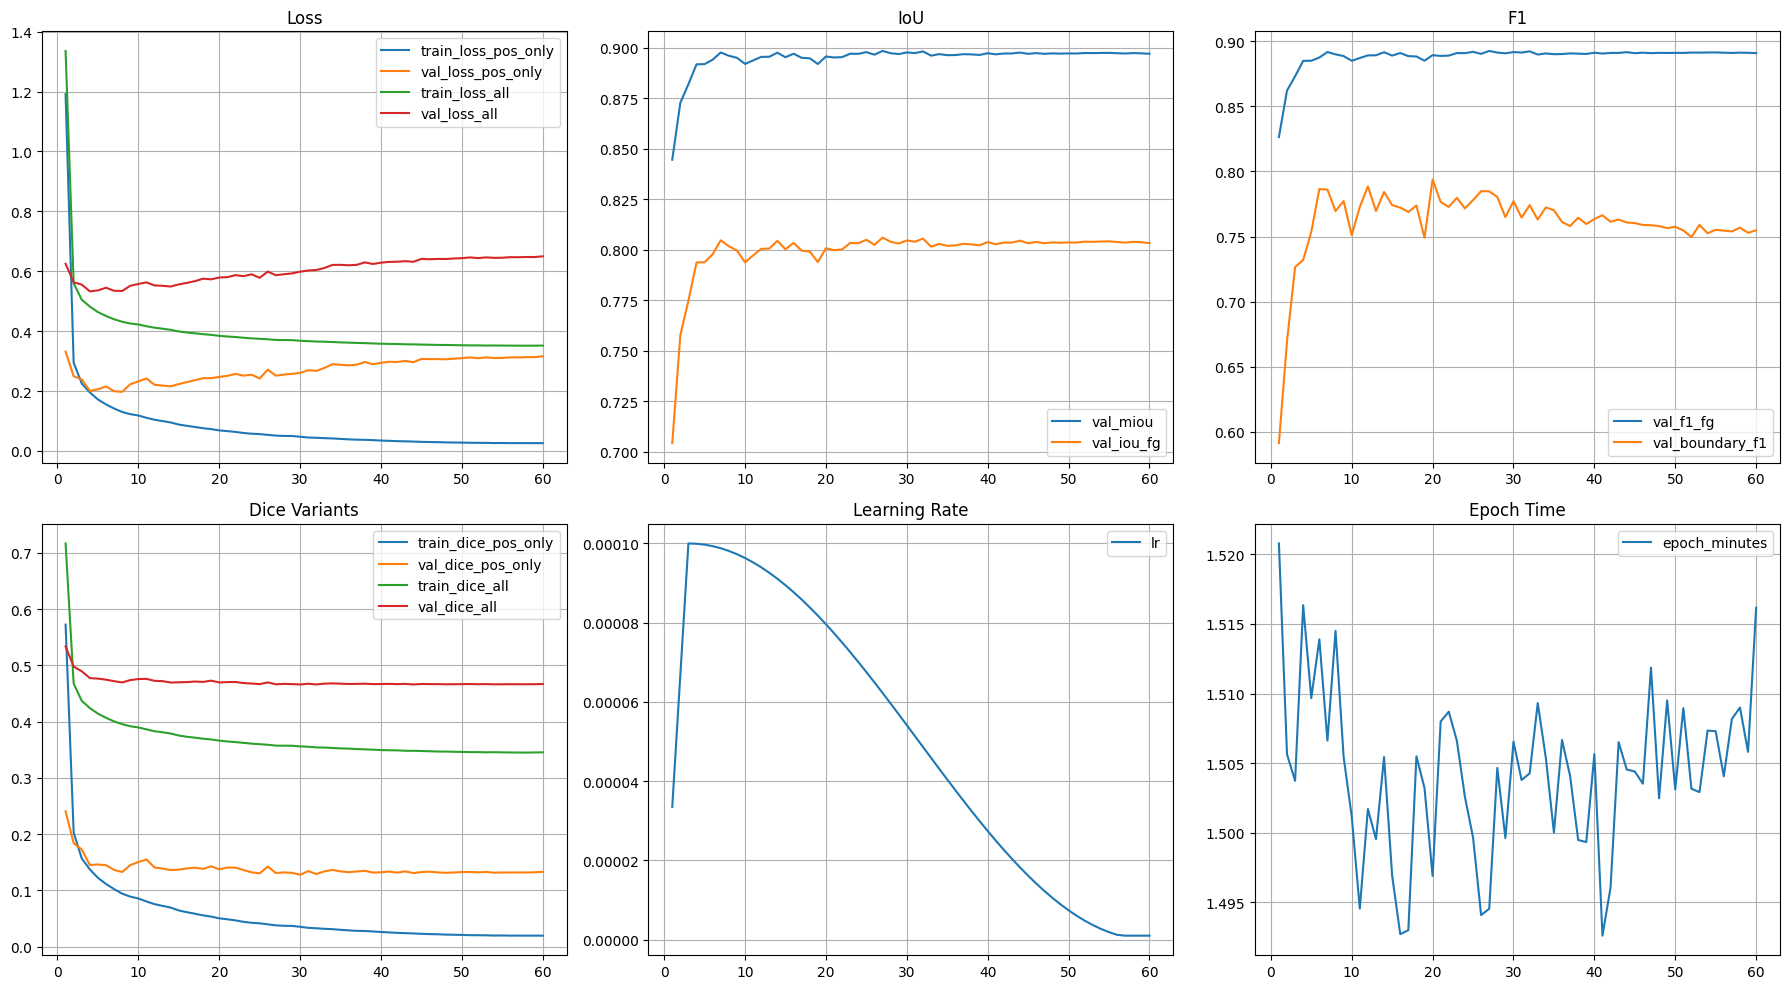

Loading best checkpoint for final val/test/inference...


Evaluating:   0%|          | 0/24 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]


===== EXPERIMENT SUMMARY =====


,run_name,run_tag,model_name,encoder_name,image_size,epochs,batch_size,eval_batch_size,lr,weight_decay,...,test_f1_fg,test_precision,test_recall,test_pixel_acc,test_boundary_f1,inference_ms_per_image,param_total_m,param_trainable_m,run_dir,status
0,fpn_r34_A100_cmp,fpn_r34_A100_cmp,FPN-ResNet34,resnet34,512,60,32,32,0.0001,0.0001,...,0.898152,0.91144,0.885246,0.989263,0.75305,1.879559,23.155393,23.155393,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...,success


...

Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

fpn_r50_A100_cmp | Epoch 059 | train_loss(pos)=0.0221 | train_loss(all)=0.3482 | val_loss(pos)=0.3248 | val_loss(all)=0.6488 | val_mIoU=0.8983 | val_IoU_fg=0.8057 | val_F1_fg=0.8924 | val_BF1=0.7505 | time=1.59 min


fpn_r50_A100_cmp | Epoch 60/60:   0%|          | 0/247 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

fpn_r50_A100_cmp | Epoch 060 | train_loss(pos)=0.0223 | train_loss(all)=0.3483 | val_loss(pos)=0.3276 | val_loss(all)=0.6515 | val_mIoU=0.8980 | val_IoU_fg=0.8051 | val_F1_fg=0.8920 | val_BF1=0.7622 | time=1.59 min


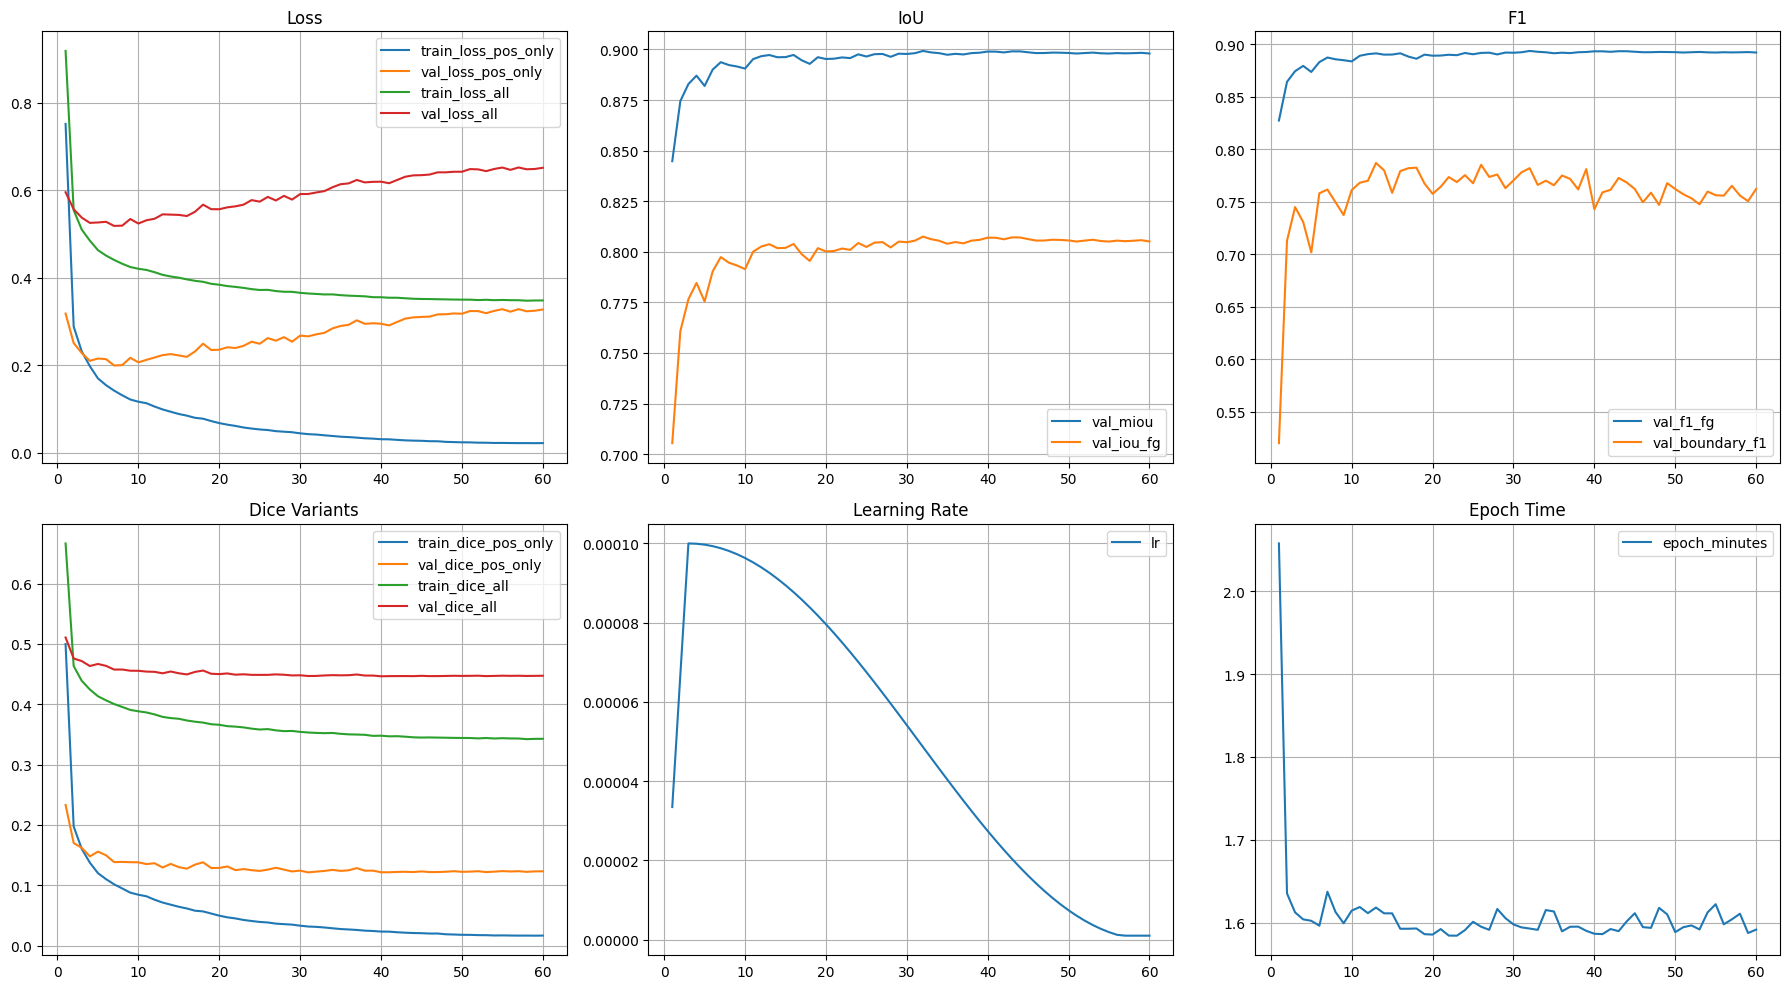

Loading best checkpoint for final val/test/inference...


Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]


===== EXPERIMENT SUMMARY =====


,run_name,run_tag,model_name,encoder_name,image_size,epochs,batch_size,eval_batch_size,lr,weight_decay,...,test_f1_fg,test_precision,test_recall,test_pixel_acc,test_boundary_f1,inference_ms_per_image,param_total_m,param_trainable_m,run_dir,status
0,fpn_r50_A100_cmp,fpn_r50_A100_cmp,FPN-ResNet50,resnet50,512,60,24,24,0.0001,0.0001,...,0.894672,0.912226,0.877781,0.988947,0.765647,2.747136,26.116033,26.116033,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...,success


...

Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

fpn_r101_A100_cmp | Epoch 059 | train_loss(pos)=0.0168 | train_loss(all)=0.3444 | val_loss(pos)=0.3404 | val_loss(all)=0.6794 | val_mIoU=0.9007 | val_IoU_fg=0.8104 | val_F1_fg=0.8952 | val_BF1=0.7719 | time=1.83 min


fpn_r101_A100_cmp | Epoch 60/60:   0%|          | 0/370 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

fpn_r101_A100_cmp | Epoch 060 | train_loss(pos)=0.0169 | train_loss(all)=0.3446 | val_loss(pos)=0.3427 | val_loss(all)=0.6817 | val_mIoU=0.9002 | val_IoU_fg=0.8093 | val_F1_fg=0.8946 | val_BF1=0.7634 | time=1.82 min


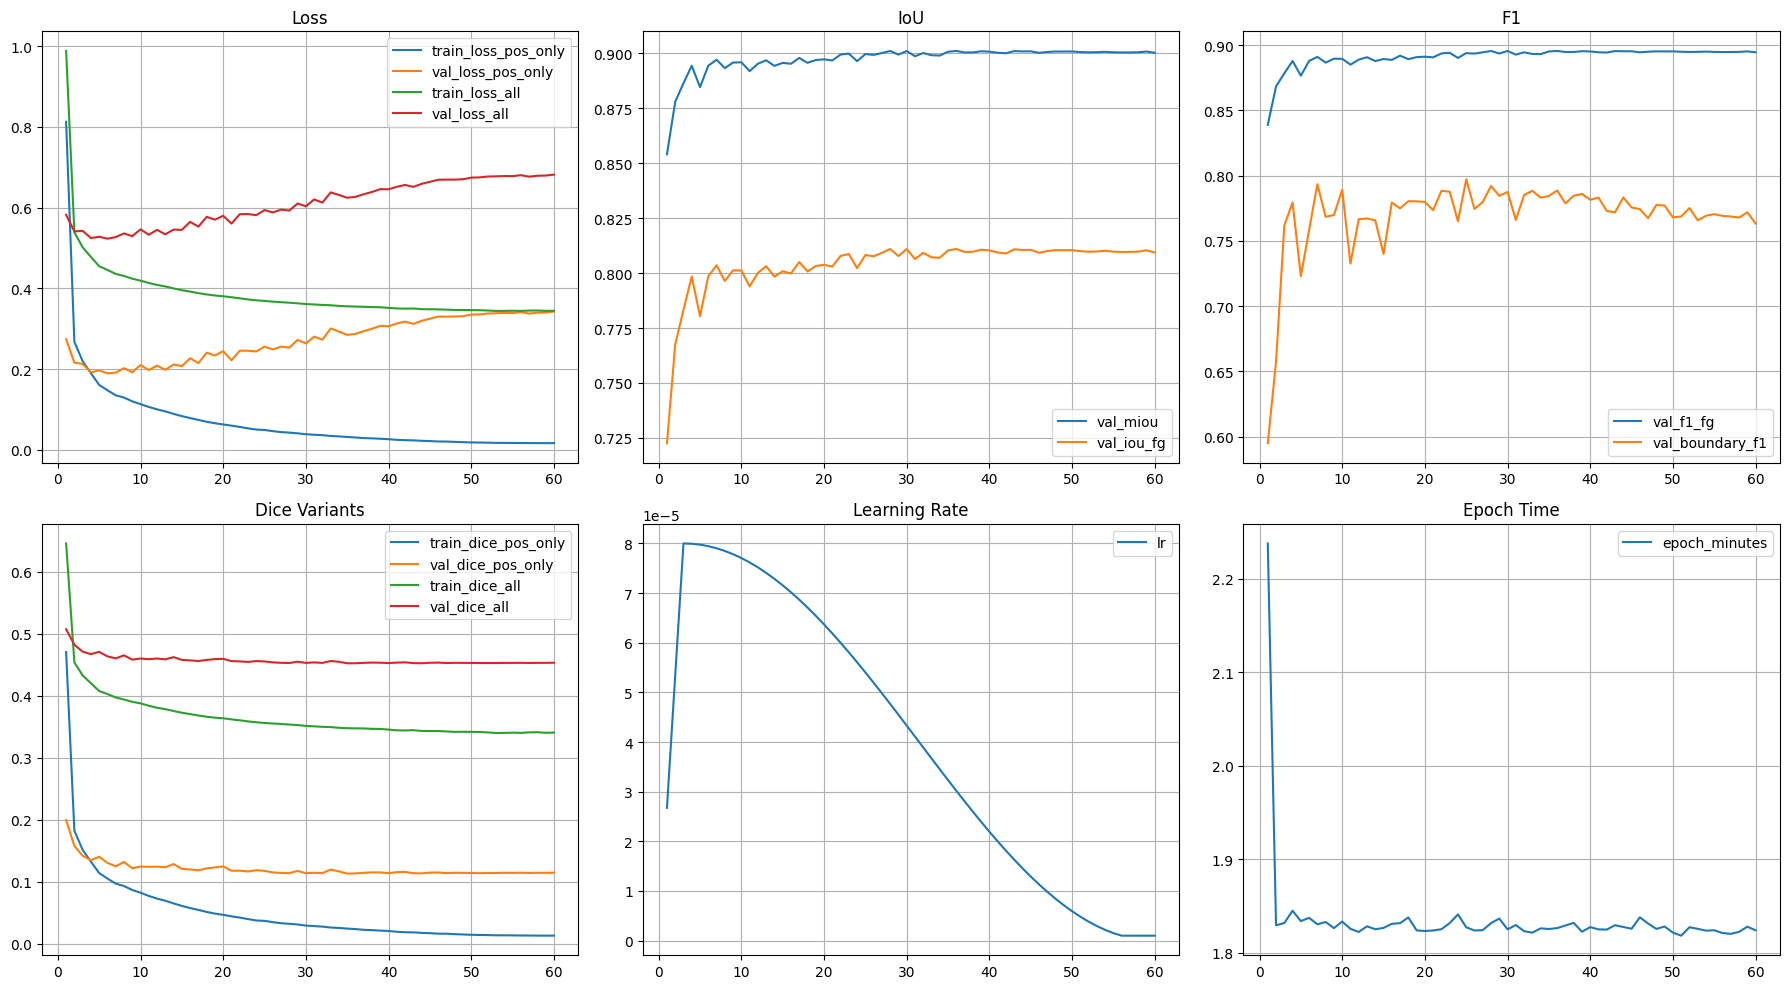

Loading best checkpoint for final val/test/inference...


Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/46 [00:00<?, ?it/s]


===== EXPERIMENT SUMMARY =====


,run_name,run_tag,model_name,encoder_name,image_size,epochs,batch_size,eval_batch_size,lr,weight_decay,...,test_f1_fg,test_precision,test_recall,test_pixel_acc,test_boundary_f1,inference_ms_per_image,param_total_m,param_trainable_m,run_dir,status
0,fpn_r101_A100_cmp,fpn_r101_A100_cmp,FPN-ResNet101,resnet101,512,60,16,16,0.00008,0.0001,...,0.899973,0.91633,0.88419,0.989489,0.790241,4.146566,45.108161,45.108161,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...,success


Finished current experiment.
Saved multi-run results -> /content/drive/MyDrive/Lab2025/LiuZhentao/Blurred Marking/20260402-new/Outputs_A100_fpn_compare-0417/multi_run_results.csv


,run_name,run_tag,model_name,encoder_name,image_size,epochs,batch_size,eval_batch_size,lr,weight_decay,...,test_f1_fg,test_precision,test_recall,test_pixel_acc,test_boundary_f1,inference_ms_per_image,param_total_m,param_trainable_m,run_dir,status
0,fpn_r34_A100_cmp,fpn_r34_A100_cmp,FPN-ResNet34,resnet34,512,60,32,32,0.00010,0.0001,...,0.898152,0.911440,0.885246,0.989263,0.753050,1.879559,23.155393,23.155393,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...,success
1,fpn_r50_A100_cmp,fpn_r50_A100_cmp,FPN-ResNet50,resnet50,512,60,24,24,0.00010,0.0001,...,0.894672,0.912226,0.877781,0.988947,0.765647,2.747136,26.116033,26.116033,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...,success
2,fpn_r101_A100_cmp,fpn_r101_A100_cmp,FPN-ResNet101,resnet101,512,60,16,16,0.00008,0.0001,...,0.899973,0.916330,0.884190,0.989489,0.790241,4.146566,45.108161,45.108161,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...,success


Found summary files: 3
Saved merged summary -> /content/drive/MyDrive/Lab2025/LiuZhentao/Blurred Marking/20260402-new/Outputs_A100_fpn_compare-0417/all_run_summaries.csv


,run_name,run_tag,model_name,encoder_name,image_size,epochs,batch_size,eval_batch_size,lr,weight_decay,...,test_f1_fg,test_precision,test_recall,test_pixel_acc,test_boundary_f1,inference_ms_per_image,param_total_m,param_trainable_m,run_dir,status
0,fpn_r101_A100_cmp,fpn_r101_A100_cmp,FPN-ResNet101,resnet101,512,60,16,16,0.00008,0.0001,...,0.899973,0.916330,0.884190,0.989489,0.790241,4.146566,45.108161,45.108161,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...,success
1,fpn_r34_A100_cmp,fpn_r34_A100_cmp,FPN-ResNet34,resnet34,512,60,32,32,0.00010,0.0001,...,0.898152,0.911440,0.885246,0.989263,0.753050,1.879559,23.155393,23.155393,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...,success
2,fpn_r50_A100_cmp,fpn_r50_A100_cmp,FPN-ResNet50,resnet50,512,60,24,24,0.00010,0.0001,...,0.894672,0.912226,0.877781,0.988947,0.765647,2.747136,26.116033,26.116033,/content/drive/MyDrive/Lab2025/LiuZhentao/Blur...,success


In [ ]:
all_results = []

for idx, cfg in enumerate(EXPERIMENTS, 1):
    print("\n" + "#" * 120)
    print(f"Starting experiment {idx}/{len(EXPERIMENTS)}: {cfg['run_tag']}")
    print("#" * 120 + "\n")

    try:
        summary = run_one_experiment(cfg)
        all_results.append(summary)

    except Exception as e:
        print(f"[FAILED] {cfg['run_tag']}")
        traceback.print_exc()

        fail_summary = {
            "run_name": None,
            "run_tag": cfg.get("run_tag", "unknown"),
            "model_name": cfg.get("model_name", "unknown"),
            "encoder_name": cfg.get("encoder_name", "unknown"),
            "image_size": cfg.get("image_size", None),
            "epochs": cfg.get("epochs", None),
            "batch_size": cfg.get("train_batch_size", None),
            "eval_batch_size": cfg.get("eval_batch_size", None),
            "lr": cfg.get("lr", None),
            "weight_decay": cfg.get("weight_decay", None),
            "optimizer": cfg.get("optimizer_name", None),
            "loss_name": cfg.get("loss_name", None),
            "status": "failed",
            "error": str(e),
            "run_dir": None,
        }
        all_results.append(fail_summary)
        cleanup_memory()

    print("Finished current experiment.")
    cleanup_memory()
    time.sleep(3)

results_df = pd.DataFrame(all_results)
results_df_path = OUTPUT_ROOT / "multi_run_results.csv"
results_df.to_csv(results_df_path, index=False)

print("Saved multi-run results ->", results_df_path)
display(results_df)


# -------------------------
# Merged summary collection
# -------------------------
summary_files = sorted(OUTPUT_ROOT.glob("*/summary.csv"))
print("Found summary files:", len(summary_files))

all_rows = []
for sf in summary_files:
    try:
        df = pd.read_csv(sf)
        if len(df) > 0:
            all_rows.append(df.iloc[0].to_dict())
    except Exception as e:
        print(f"Skip {sf}: {e}")

if len(all_rows) == 0:
    print("No valid summary.csv found.")
else:
    all_df = pd.DataFrame(all_rows)
    if "test_miou" in all_df.columns:
        all_df = all_df.sort_values("test_miou", ascending=False)

    save_path = OUTPUT_ROOT / "all_run_summaries.csv"
    all_df.to_csv(save_path, index=False)

    print("Saved merged summary ->", save_path)
    display(all_df)
